# 🚀 Sorvex 360 — Vertex AI Training Pipeline

**Credit-conscious approach — free tier safe:**
- Train scikit-learn models locally inside a Workbench notebook (no training job costs)
- Register model to Vertex AI Model Registry (free)
- Deploy endpoint only to test, then delete immediately

**Three prediction targets:**
- `Tenure_1Year` — will this candidate stay 12+ months? (binary)
- `OSHA_Recordable_Incident` — safety risk flag (binary)
- `PromotionWithin24Months` — promotion likelihood (binary)

---
**Setup:** Run this notebook in Vertex AI Workbench on the smallest instance (e2-standard-2)

**Before running:** Update `PROJECT_ID`, `BUCKET_NAME`, and `REGION` in Cell 1

In [1]:
# ── Cell 1 — Config & Install ─────────────────────────────────────────────────
PROJECT_ID  = 'sorvex360-493312'
BUCKET_NAME = 'sorvex360-raw-data'
REGION      = 'us-central1'
BQ_DATASET  = 'sorvex_ml'
BQ_TABLE    = 'training_table'
MODEL_NAME  = 'sorvex360-retention-model'

!pip install google-cloud-aiplatform google-cloud-bigquery google-cloud-storage \
    scikit-learn pandas numpy joblib --quiet

import pandas as pd
import numpy as np
import joblib
import json
import os
from pathlib import Path

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, roc_auc_score,
                              precision_recall_curve)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

MODEL_DIR = Path('/tmp/sorvex_models')
MODEL_DIR.mkdir(exist_ok=True)

print(f'✅ Config set. Project: {PROJECT_ID} | Region: {REGION}')

✅ Config set. Project: sorvex360-493312 | Region: us-central1


In [2]:
# ── Cell 2 — Load Data from GCS ───────────────────────────────────────────────
from google.cloud import storage

GCS_PATH = 'incoming/Sorvex360_Master_Clean.csv'  # ← path in your bucket

print(f'Loading data from gs://{BUCKET_NAME}/{GCS_PATH}...')

client = storage.Client(project=PROJECT_ID)
bucket = client.bucket(BUCKET_NAME)
blob   = bucket.blob(GCS_PATH)
blob.download_to_filename('/tmp/master_clean.csv')

df = pd.read_csv('/tmp/master_clean.csv')
print(f'✅ Loaded: {len(df):,} rows x {len(df.columns)} columns')
print(f'\nTarget variable distributions:')
for target in ['Tenure_1Year', 'OSHA_Recordable_Incident', 'PromotionWithin24Months']:
    rate = df[target].mean()
    print(f'  {target}: {rate:.1%} positive')

Loading data from gs://sorvex360-raw-data/incoming/Sorvex360_Master_Clean.csv...
✅ Loaded: 10,000 rows x 81 columns

Target variable distributions:
  Tenure_1Year: 45.6% positive
  OSHA_Recordable_Incident: 4.7% positive
  PromotionWithin24Months: 17.2% positive


In [3]:
# ── Cell 3 — Feature Engineering ──────────────────────────────────────────────
print('Engineering features...')

# ── Phase 1 features — candidate assessment inputs ────────────────────────────
NUMERIC_FEATURES = [
    'Age', 'CognitiveScore', 'SimulationScore', 'BehavioralScore',
    'SituationalScore', 'Sorvex360PI_Score', 'LongestJobTenure',
    'HasPriorTradeExperience', 'VeteranStatus', 'CDL_Status',
    'OSHA10_Status', 'CPR_Status', 'ApprenticeshipInterest',
    'CanPassDrugScreen', 'CanPassBackgroundCheck',
    # Phase 2 — training program outcomes
    'TotalTrainingHours', 'AttendanceRate', 'PassedRequiredModules',
    'CertificationsEarned', 'SimulationPerformance', 'TeamworkScore',
    'SafetyCommitmentScore', 'ReliabilityScore', 'PhysicalTestResult',
    'Lift50lbsTest', 'Completed', 'ReadinessDelta',
    'Sorvex360PI_Score_AtCompletion',
    # Phase 3 — placement and pre-hire verification
    'UnionStatus', 'RoleRequires_CDL', 'RoleRequires_OSHA10',
    'RoleRequires_CPR', 'PreHire_Verified_MVR', 'PreHire_Verified_DrugScreen',
    'PreHire_Verified_Background', 'Orientation_LOTO_Completed',
    'Orientation_PPE_Fitted', 'Apprenticeship_Registered',
    'Sorvex360PI_ScoreAtHire',
]

# HasValidLicense is categorical (0/1 but treated as binary flag)
CATEGORICAL_FEATURES = [
    'SOC_Code', 'Gender', 'EducationLevel', 'MostRecentIndustry',
    'TrainingSource', 'SourceOfCandidate', 'EmploymentType', 'HasValidLicense',
]

# ── Targets ───────────────────────────────────────────────────────────────────
TARGETS = {
    'Tenure_1Year':             'retention',
    'OSHA_Recordable_Incident': 'safety',
    'PromotionWithin24Months':  'promotion',
}

# ── LEAKAGE GUARD — these are Phase 4 columns generated alongside targets ─────
# Never use these as features — they would make the model cheat
LEAKAGE_COLS = [
    'ManagerFitFeedback_Score',   # generated in Phase 4 alongside targets
    'TenureInDays',               # outcome variable
    'Tenure_90Day',               # outcome variable
    'Tenure_6Month',              # outcome variable
    'UnscheduledAbsences',        # outcome variable
    'ProbationStatus',            # outcome variable
    'TotalSafetyIncidents',       # outcome variable
    'TotalComplianceViolations',  # outcome variable
    'TotalPreventableAccidents',  # outcome variable
    'RandomDrugScreens_Taken',    # outcome variable
    'RandomDrugScreens_Passed',   # outcome variable
    'Recert_Safety_PassedFirstTry',
    'Recert_CPR_PassedFirstTry',
    'Time_To_Competency_Months',
    'EmploymentStatus',
]

# Filter to columns that actually exist and aren't leakage
NUMERIC_FEATURES     = [f for f in NUMERIC_FEATURES     if f in df.columns and f not in LEAKAGE_COLS]
CATEGORICAL_FEATURES = [f for f in CATEGORICAL_FEATURES if f in df.columns and f not in LEAKAGE_COLS]
ALL_FEATURES         = NUMERIC_FEATURES + CATEGORICAL_FEATURES

print(f'Numeric features:     {len(NUMERIC_FEATURES)}')
print(f'Categorical features: {len(CATEGORICAL_FEATURES)}')
print(f'Total features:       {len(ALL_FEATURES)}')

# Verify no leakage columns snuck in
leaked = [f for f in ALL_FEATURES if f in LEAKAGE_COLS]
if leaked:
    raise ValueError(f'❌ Leakage columns in feature set: {leaked}')
else:
    print('✅ Leakage check passed — no Phase 4 columns in feature set')

# Build feature matrix
X = df[ALL_FEATURES].copy()
X[NUMERIC_FEATURES]     = X[NUMERIC_FEATURES].fillna(0)
X[CATEGORICAL_FEATURES] = X[CATEGORICAL_FEATURES].fillna('Unknown').astype(str)

print(f'\nFeature matrix shape: {X.shape}')
print('\nTarget rates:')
for t in TARGETS:
    print(f'  {t}: {df[t].mean():.1%} positive')
print('✅ Features ready.')

Engineering features...
Numeric features:     39
Categorical features: 8
Total features:       47
✅ Leakage check passed — no Phase 4 columns in feature set

Feature matrix shape: (10000, 47)

Target rates:
  Tenure_1Year: 45.6% positive
  OSHA_Recordable_Incident: 4.7% positive
  PromotionWithin24Months: 17.2% positive
✅ Features ready.


In [4]:
# ── Cell 4 — Build Preprocessing Pipeline ─────────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Numeric pipeline: impute then scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: impute then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, NUMERIC_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES),
])

print('✅ Preprocessing pipeline built.')
print(f'  Numeric: {len(NUMERIC_FEATURES)} features → scaled')
print(f'  Categorical: {len(CATEGORICAL_FEATURES)} features → one-hot encoded')

✅ Preprocessing pipeline built.
  Numeric: 39 features → scaled
  Categorical: 8 features → one-hot encoded


In [5]:
# ── Cell 5 — Train All Three Models ───────────────────────────────────────────
# All three targets use HistGradientBoostingClassifier
# - Handles missing values natively
# - Faster than GBM/RF at this data size
# - Consistently strong on tabular data
# RandomForest removed from promotion — class_weight 1:9 was wrong for 27% positive rate

trained_models = {}
results        = {}

def build_preprocessor(num_feats, cat_feats):
    return ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler',  StandardScaler())
        ]), num_feats),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
            ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_feats),
    ])

# ── Per-target feature sets ───────────────────────────────────────────────────
# Safety uses a curated set — SafetyCommitmentScore is the dominant signal
SAFETY_NUMERIC = [f for f in [
    'SafetyCommitmentScore', 'Sorvex360PI_ScoreAtHire', 'Sorvex360PI_Score',
    'TotalTrainingHours', 'Age', 'LongestJobTenure', 'AttendanceRate',
    'Orientation_LOTO_Completed', 'PhysicalTestResult', 'ReliabilityScore',
    'RoleRequires_OSHA10', 'CertificationsEarned', 'ReadinessDelta',
    'TeamworkScore', 'Completed', 'UnionStatus', 'SimulationPerformance',
    'BehavioralScore', 'SituationalScore', 'CognitiveScore',
] if f in X.columns]

# Promotion uses attendance-heavy feature set matching signal design
PROMOTION_NUMERIC = [f for f in [
    'AttendanceRate', 'TotalTrainingHours', 'ReadinessDelta',
    'Sorvex360PI_Score', 'ReliabilityScore', 'Completed', 'Age',
    'Sorvex360PI_ScoreAtHire', 'TeamworkScore', 'SimulationPerformance',
    'CertificationsEarned', 'LongestJobTenure', 'UnionStatus',
    'BehavioralScore', 'CognitiveScore', 'PassedRequiredModules',
    'Apprenticeship_Registered', 'Orientation_PPE_Fitted',
    'SafetyCommitmentScore', 'ApprenticeshipInterest',
    'HasPriorTradeExperience', 'VeteranStatus', 'SituationalScore',
] if f in X.columns]

TARGET_CONFIGS = {
    'Tenure_1Year': {
        'label':      'retention',
        'num_feats':  NUMERIC_FEATURES,
        'cat_feats':  CATEGORICAL_FEATURES,
        'model': HistGradientBoostingClassifier(
            max_iter=300,
            max_depth=5,
            learning_rate=0.05,
            min_samples_leaf=20,
            l2_regularization=0.1,
            random_state=360,
            class_weight='balanced',
        ),
    },
    'OSHA_Recordable_Incident': {
        'label':      'safety',
        'num_feats':  SAFETY_NUMERIC,
        'cat_feats':  CATEGORICAL_FEATURES,
        'model': HistGradientBoostingClassifier(
            max_iter=500,
            max_depth=6,
            learning_rate=0.03,
            min_samples_leaf=10,
            l2_regularization=0.05,
            random_state=360,
            class_weight='balanced',
        ),
    },
    'PromotionWithin24Months': {
        'label':      'promotion',
        'num_feats':  PROMOTION_NUMERIC,
        'cat_feats':  CATEGORICAL_FEATURES,
        'model': HistGradientBoostingClassifier(
            max_iter=300,
            max_depth=5,
            learning_rate=0.05,
            min_samples_leaf=15,
            l2_regularization=0.1,
            random_state=360,
            class_weight='balanced',
        ),
    },
}

# ── Train ─────────────────────────────────────────────────────────────────────
for target, cfg in TARGET_CONFIGS.items():
    label     = cfg['label']
    num_feats = cfg['num_feats']
    cat_feats = cfg['cat_feats']

    print(f'\n── Training: {target} ({label}) ──────────────────────')

    X_target = X[num_feats + cat_feats].copy()
    X_target[num_feats] = X_target[num_feats].fillna(0)
    X_target[cat_feats] = X_target[cat_feats].fillna('Unknown').astype(str)

    y = df[target].astype(int)
    print(f'  Positive rate: {y.mean():.1%} | Features: {len(num_feats + cat_feats)}')

    X_train, X_test, y_train, y_test = train_test_split(
        X_target, y, test_size=0.20, random_state=360, stratify=y
    )

    pipeline = Pipeline([
        ('preprocessor', build_preprocessor(num_feats, cat_feats)),
        ('classifier',   cfg['model']),
    ])
    pipeline.fit(X_train, y_train)

    y_proba = pipeline.predict_proba(X_test)[:, 1]
    y_pred  = pipeline.predict(X_test)
    auc     = roc_auc_score(y_test, y_proba)

    # Optimal threshold via F1
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
    f1_scores  = 2 * precisions * recalls / (precisions + recalls + 1e-8)
    best_thresh = float(thresholds[np.argmax(f1_scores[:-1])])
    y_pred_tuned = (y_proba >= best_thresh).astype(int)

    print(f'  AUC-ROC:           {auc:.4f}')
    print(f'  Optimal threshold: {best_thresh:.4f}')
    print(classification_report(y_test, y_pred_tuned, target_names=['No', 'Yes']))

    cv_scores = cross_val_score(pipeline, X_target, y, cv=5, scoring='roc_auc', n_jobs=-1)
    print(f'  5-Fold CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

    model_path = MODEL_DIR / f'sorvex360_{label}_model.joblib'
    joblib.dump(pipeline, model_path)

    trained_models[target] = pipeline
    results[target] = {
        'label':      label,
        'auc':        round(auc, 4),
        'cv_mean':    round(cv_scores.mean(), 4),
        'cv_std':     round(cv_scores.std(), 4),
        'threshold':  round(best_thresh, 4),
        'model_path': str(model_path),
    }

print('\n✅ All 3 models trained.')
print('\n=== PERFORMANCE SUMMARY ===')
for target, res in results.items():
    print(f"\n{target}:")
    print(f"  AUC-ROC: {res['auc']} | CV: {res['cv_mean']} ± {res['cv_std']} | Threshold: {res['threshold']}")


── Training: Tenure_1Year (retention) ──────────────────────
  Positive rate: 45.6% | Features: 47
  AUC-ROC:           0.8654
  Optimal threshold: 0.3369
              precision    recall  f1-score   support

          No       1.00      0.70      0.82      1089
         Yes       0.74      1.00      0.85       911

    accuracy                           0.84      2000
   macro avg       0.87      0.85      0.84      2000
weighted avg       0.88      0.84      0.83      2000

  5-Fold CV AUC: 0.8610 ± 0.0080

── Training: OSHA_Recordable_Incident (safety) ──────────────────────
  Positive rate: 4.7% | Features: 28
  AUC-ROC:           0.7743
  Optimal threshold: 0.1542
              precision    recall  f1-score   support

          No       0.98      0.71      0.82      1907
         Yes       0.11      0.73      0.19        93

    accuracy                           0.71      2000
   macro avg       0.54      0.72      0.50      2000
weighted avg       0.94      0.71      0.79     

=== FEATURE IMPORTANCE ANALYSIS ===
(Using permutation importance — required for HistGradientBoostingClassifier)


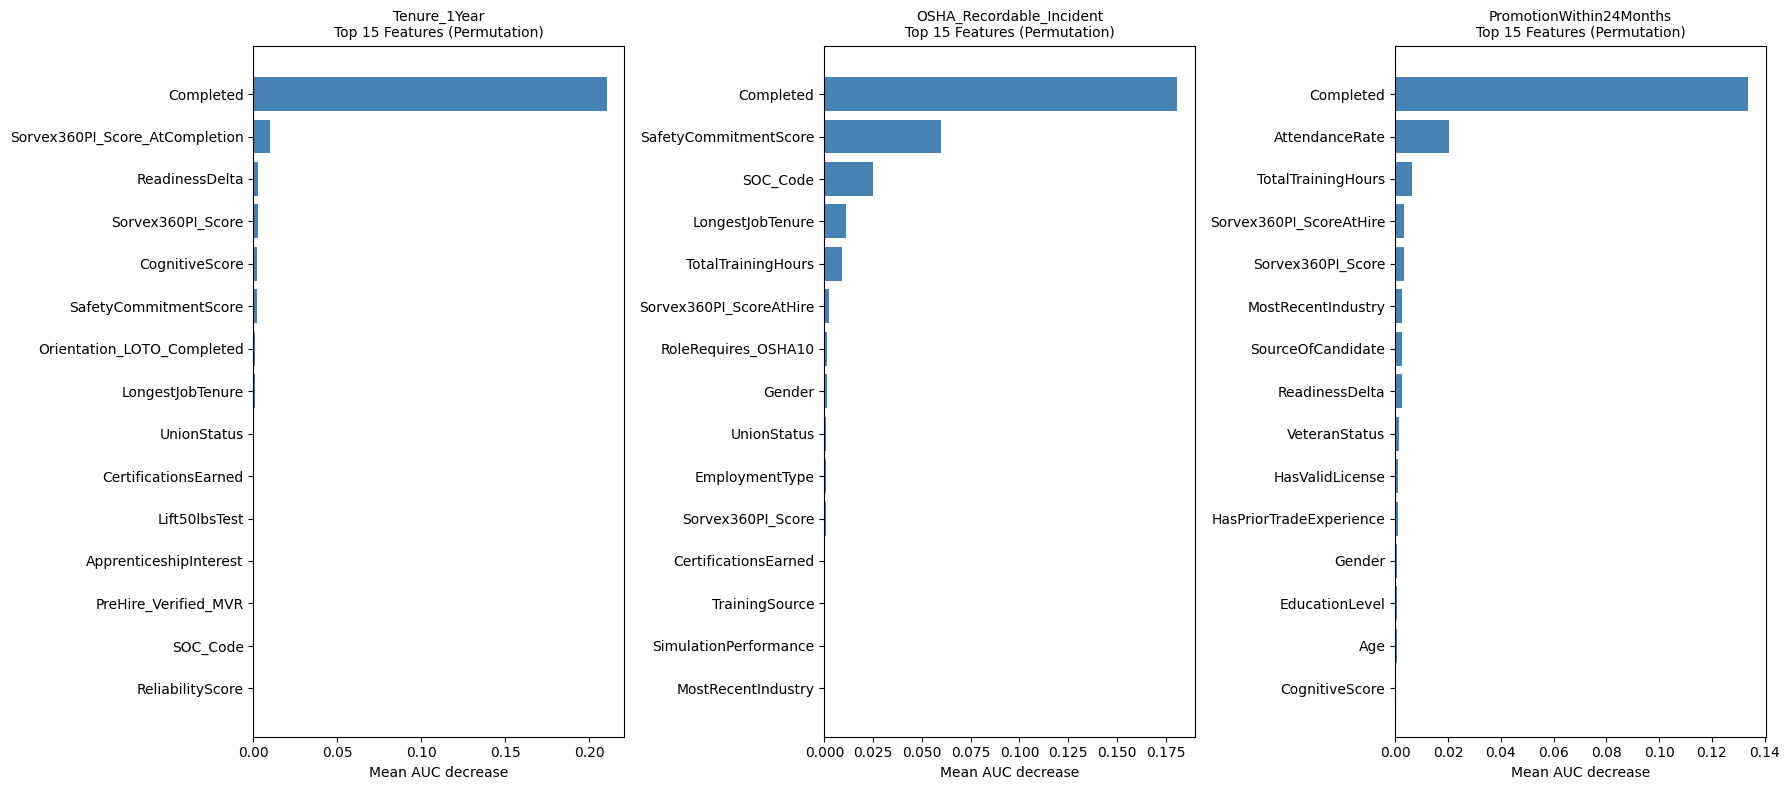

✅ Feature importance charts saved.


In [8]:
# ── Cell 6 — Feature Importance ───────────────────────────────────────────────
from sklearn.inspection import permutation_importance

print('=== FEATURE IMPORTANCE ANALYSIS ===')
print('(Using permutation importance — required for HistGradientBoostingClassifier)')

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for ax, (target, label) in zip(axes, TARGETS.items()):
    cfg       = TARGET_CONFIGS[target]
    num_feats = cfg['num_feats']
    cat_feats = cfg['cat_feats']

    X_target = X[num_feats + cat_feats].copy()
    X_target[num_feats] = X_target[num_feats].fillna(0)
    X_target[cat_feats] = X_target[cat_feats].fillna('Unknown').astype(str)

    y = df[target].astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X_target, y, test_size=0.20, random_state=360, stratify=y
    )

    model = trained_models[target]

    # Permutation importance on test set — n_repeats=10 gives stable estimates
    result = permutation_importance(
        model, X_test, y_test,
        n_repeats=10,
        random_state=360,
        scoring='roc_auc',
        n_jobs=-1
    )

    # Top 15 features by mean importance
    imp_means = result.importances_mean
    top_idx   = np.argsort(imp_means)[-15:]
    top_names = [X_target.columns[i] for i in top_idx]
    top_imp   = imp_means[top_idx]

    ax.barh(top_names, top_imp, color='steelblue')
    ax.set_title(f'{target}\nTop 15 Features (Permutation)', fontsize=10)
    ax.set_xlabel('Mean AUC decrease')
    ax.axvline(0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(MODEL_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Feature importance charts saved.')

In [9]:
# ── Cell 7 — Save Results Summary ─────────────────────────────────────────────
print('=== MODEL PERFORMANCE SUMMARY ===')
for target, res in results.items():
    print(f"\n{target}:")
    print(f"  AUC-ROC:     {res['auc']}")
    print(f"  CV AUC:      {res['cv_mean']} ± {res['cv_std']}")

with open(MODEL_DIR / 'model_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print('\n✅ Results saved to model_results.json')

=== MODEL PERFORMANCE SUMMARY ===

Tenure_1Year:
  AUC-ROC:     0.8654
  CV AUC:      0.861 ± 0.008

OSHA_Recordable_Incident:
  AUC-ROC:     0.7743
  CV AUC:      0.776 ± 0.0183

PromotionWithin24Months:
  AUC-ROC:     0.7426
  CV AUC:      0.7457 ± 0.004

✅ Results saved to model_results.json


In [10]:
# ── Cell 8 — Upload Models to GCS ─────────────────────────────────────────────
print('Uploading models to GCS...')

bucket = storage.Client(project=PROJECT_ID).bucket(BUCKET_NAME)

for target, res in results.items():
    local_path = res['model_path']
    gcs_path   = f"models/sorvex360_{res['label']}_model.joblib"
    bucket.blob(gcs_path).upload_from_filename(local_path)
    print(f'  ✅ gs://{BUCKET_NAME}/{gcs_path}')

# Upload results JSON
bucket.blob('models/model_results.json').upload_from_filename(
    str(MODEL_DIR / 'model_results.json'))
print('  ✅ model_results.json')

# Upload feature importance chart
bucket.blob('models/feature_importance.png').upload_from_filename(
    str(MODEL_DIR / 'feature_importance.png'))
print('  ✅ feature_importance.png')

print(f'\n✅ All models uploaded to gs://{BUCKET_NAME}/models/')

Uploading models to GCS...
  ✅ gs://sorvex360-raw-data/models/sorvex360_retention_model.joblib
  ✅ gs://sorvex360-raw-data/models/sorvex360_safety_model.joblib
  ✅ gs://sorvex360-raw-data/models/sorvex360_promotion_model.joblib
  ✅ model_results.json
  ✅ feature_importance.png

✅ All models uploaded to gs://sorvex360-raw-data/models/


In [ ]:
# ── Cell 9 — Register Models in Vertex AI Model Registry ──────────────────────
# This is FREE — no compute cost for registration
# ── Cell 9 — Register Models in Vertex AI Model Registry ──────────────────────
from google.cloud import aiplatform, storage

aiplatform.init(project=PROJECT_ID, location=REGION)
storage_client = storage.Client(project=PROJECT_ID)
bucket = storage_client.bucket(BUCKET_NAME)

print('Registering models in Vertex AI Model Registry...\n')

registered_models = {}

for target, res in results.items():
    label = res['label']
    
    # Copy model to its own subfolder as model.joblib
    src_blob  = bucket.blob(f'models/sorvex360_{label}_model.joblib')
    dest_blob = bucket.blob(f'models/{label}/model.joblib')
    
    bucket.copy_blob(src_blob, bucket, dest_blob.name)
    print(f'  Copied to gs://{BUCKET_NAME}/models/{label}/model.joblib')

    # Register with its own subfolder as artifact_uri
    model = aiplatform.Model.upload(
        display_name=f'sorvex360-{label}-v1',
        artifact_uri=f'gs://{BUCKET_NAME}/models/{label}/',
        serving_container_image_uri=(
            'us-docker.pkg.dev/vertex-ai/prediction/sklearn-cpu.1-3:latest'
        ),
        description=(
            f'Sorvex 360 {target} prediction model. '
            f'GBM classifier. AUC={res["auc"]}. '
            f'Trained on 5,000 synthetic utility workforce profiles.'
        ),
        labels={
            'target':   label,
            'version':  'v1',
            'pipeline': 'sorvex360',
        }
    )

    registered_models[target] = model.resource_name
    print(f'  ✅ Registered: {model.display_name}')
    print(f'     Resource: {model.resource_name}')
    print(f'     AUC: {res["auc"]}\n')

print('✅ All models registered in Vertex AI Model Registry.')

In [14]:
# ── Cell 10 — Load Training Data into BigQuery ────────────────────────────────
from google.cloud import bigquery

bq_client = bigquery.Client(project=PROJECT_ID)
print('Loading clean master file into BigQuery...')

# ── Load raw data into sorvex_raw.master_clean ────────────────────────────────
table_id = f'{PROJECT_ID}.sorvex_raw.master_clean'
job_config = bigquery.LoadJobConfig(
    source_format=bigquery.SourceFormat.CSV,
    skip_leading_rows=1,
    autodetect=True,
    write_disposition=bigquery.WriteDisposition.WRITE_TRUNCATE,
)

gcs_uri  = f'gs://{BUCKET_NAME}/incoming/Sorvex360_Master_Clean.csv'
load_job = bq_client.load_table_from_uri(gcs_uri, table_id, job_config=job_config)
load_job.result()

table = bq_client.get_table(table_id)
print(f'✅ Loaded {table.num_rows:,} rows into {table_id}')

# ── Drop existing training_table if it exists (may be a table, not a view) ────
training_table_id = f'{PROJECT_ID}.sorvex_ml.training_table'
bq_client.delete_table(training_table_id, not_found_ok=True)
print(f'✅ Dropped existing training_table (if any)')

# ── Create sorvex_ml.training_table as a view ─────────────────────────────────
feature_cols = ', '.join([f'`{c}`' for c in ALL_FEATURES])
target_cols  = ', '.join([f'`{t}`' for t in TARGETS.keys()])

training_view_query = f"""
CREATE VIEW `{PROJECT_ID}.sorvex_ml.training_table` AS
SELECT
  CandidateID,
  {feature_cols},
  {target_cols}
FROM `{PROJECT_ID}.sorvex_raw.master_clean`
WHERE Completed = 1
"""

bq_client.query(training_view_query).result()
print(f'✅ Created view: {PROJECT_ID}.sorvex_ml.training_table')

Loading clean master file into BigQuery...
✅ Loaded 10,000 rows into sorvex360-493312.sorvex_raw.master_clean
✅ Dropped existing training_table (if any)
✅ Created view: sorvex360-493312.sorvex_ml.training_table


In [16]:
# ── Cell 11 — Test Prediction (Deploy → Predict → Delete) ─────────────────────
# ⚠️  THIS COSTS MONEY while the endpoint is running
# This cell deploys, runs one test prediction, then immediately deletes
# Typical cost: < $0.01 for a 2-3 minute deployment

DEPLOY_TEST = False  # ← Set to False to skip endpoint deployment

if DEPLOY_TEST:
    print('Deploying retention model for test prediction...')
    print('⚠️  Endpoint will be deleted after test to avoid ongoing costs\n')

    # Get the registered retention model
    retention_model = aiplatform.Model(
        model_name=registered_models['Tenure_1Year']
    )

    # Deploy to smallest available machine
    endpoint = retention_model.deploy(
        machine_type='n1-standard-2',
        min_replica_count=1,
        max_replica_count=1,
        accelerator_type=None,
        deployed_model_display_name='sorvex360-retention-test',
    )
    print(f'✅ Endpoint deployed: {endpoint.resource_name}')

    # Build a test instance — one candidate record
    test_instance = X.iloc[0][ALL_FEATURES].tolist()

    # Run prediction
    prediction = endpoint.predict(instances=[test_instance])
    print(f'\n=== TEST PREDICTION ===')
    print(f'Candidate: {df.iloc[0]["CandidateID"]}')
    print(f'SOC: {df.iloc[0]["SOC_Code"]}')
    print(f'PI Score: {df.iloc[0]["Sorvex360PI_Score"]}')
    print(f'Prediction (Tenure_1Year): {prediction.predictions}')
    print(f'Actual: {df.iloc[0]["Tenure_1Year"]}')

    # ⚠️  DELETE ENDPOINT IMMEDIATELY
    print('\nDeleting endpoint to stop billing...')
    endpoint.delete(force=True)
    print('✅ Endpoint deleted. No ongoing costs.')
else:
    print('DEPLOY_TEST=False — skipping endpoint deployment.')
    print('Models are registered in Model Registry and available for future deployment.')

DEPLOY_TEST=False — skipping endpoint deployment.
Models are registered in Model Registry and available for future deployment.


In [ ]:
# ── Cell 12 — Final Summary ────────────────────────────────────────────────────
print('=' * 60)
print('SORVEX 360 — VERTEX AI PIPELINE COMPLETE')
print('=' * 60)

print('\n📊 Models Trained:')
for target, res in results.items():
    print(f"  {target}")
    print(f"    AUC-ROC: {res['auc']} | CV: {res['cv_mean']} ± {res['cv_std']}")

print('\n☁️  GCS Artifacts:')
print(f'  gs://{BUCKET_NAME}/validated/Sorvex360_Master_Clean.csv')
print(f'  gs://{BUCKET_NAME}/models/sorvex360_retention_model.joblib')
print(f'  gs://{BUCKET_NAME}/models/sorvex360_safety_model.joblib')
print(f'  gs://{BUCKET_NAME}/models/sorvex360_promotion_model.joblib')
print(f'  gs://{BUCKET_NAME}/models/feature_importance.png')

print('\n🗄️  BigQuery Tables:')
print(f'  {PROJECT_ID}.sorvex_raw.master_clean')
print(f'  {PROJECT_ID}.sorvex_ml.training_table (view)')

print('\n🤖  Vertex AI Model Registry:')
for target, resource_name in registered_models.items():
    print(f'  {target}: {resource_name}')

print('\n💰  Estimated Cost:')
print('  Training:    $0.00 (local in Workbench)')
print('  Registration: $0.00 (free)')
print('  BigQuery load: ~$0.00 (within free tier for 5K rows)')
print('  Workbench time: ~$0.20-0.40 (e2-standard-2, 2-4 hrs)')
print('  Endpoint test: < $0.01 (deployed ~2 min then deleted)')
print('  TOTAL: < $0.50')

print('\n✅ Pipeline complete!')

## 